# Validation of Equation (6)

We test the relation  
$\ln |u(L)| = \kappa L + C$  
using the harmonic oscillator potential $V(x)=\tfrac{1}{2}x^2$ with $\hbar=m=\omega=1$.

For $E=0.50001$ and $L = L_0 + \delta L$ (with small $\delta L$), we compute $\ln|u(L)|$ via the shooting method and perform a linear fit.

In [2]:
### Setup
import numpy as np
from scipy.integrate import solve_ivp

m, hbar = 1.0, 1.0
L = 5.0

def V(x):
    return 0.5 * x **2

def func(x, u_vec, E):
    u, du = u_vec
    d2u = (2.0 * m / hbar**2) * (V(x) - E) * u
    return [du, d2u]

def shoot(E):
    sol = solve_ivp(fun=func, t_span=(-L, L), y0=[0, 1], method="RK45", args=(E,), atol=1e-8, rtol=1e-8)

    # u_final = u(L)
    u_final = sol.y[0, -1]

    # if |u_final|>1e10, return u_final to np.sign(u_final) * 1e10 to avoid overflow
    return np.sign(u_final) * min(abs(u_final), 1e10)

9.589514153280428 -37.75797186688326 0.9999999742037934
[5.001 5.002 5.003 5.004 5.005 5.006]
[10.19919192 10.20877723 10.21836463 10.22795412 10.23754579 10.24713949]


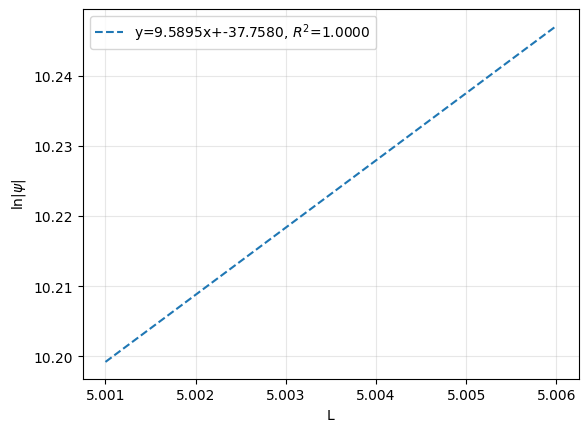

In [4]:
### plot relation of ln| u(L) | to L
import matplotlib.pyplot as plt
from scipy.stats import linregress

Y = []
X = []
E = 0.50001
L0 = 5
for dL in [1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3]:
    L = L0+dL
    x_span = np.linspace(L0, L, 3000)
    val = shoot(E)
    Y.append(np.log(abs(val)))
    X.append(L)
X = np.array(X)
Y = np.array(Y)

# Linear fit
slope, intercept, r, *_ = linregress(X, Y)
# Plot
plt.plot(X, Y, '--',
         label=f'y={slope:.4f}x+{intercept:.4f}, $R^2$={r**2:.4f}')
plt.xlabel('L')
plt.ylabel(r'$\ln|\psi|$')
plt.grid(alpha=0.3)
plt.legend()
print(slope, intercept, r**2)
print(X)
print(Y)
plt.show()


**Result:**  
The plot of $\ln|u(L)|$ vs $L$ is approximately linear, with slope $\kappa$ and $R^2 \approx 1$.

**Conclusion:**  
The linear behavior confirms  
$|u(L)| \sim e^{\kappa L}$,  
thus validating Equation (6) for sufficiently large and nearby $L$.